In [122]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (4, 2)

In [123]:
def g(x):
    return 3*x**2 - 4*x + 5

In [124]:
g(3.0)

20.0

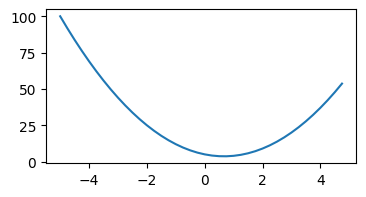

In [125]:
xs = np.arange(-5,5,0.25)
ys = g(xs)
plt.plot(xs,ys)

In [126]:
class Value:

    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self,other):
        return self + other  

    def __sub__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, (self,other), '-')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += -1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float)), "supports int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other -1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other): #other * self
        return self*other

    def __truediv__(self,other):
        return (self * other**-1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)


        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [127]:
a = Value(2.0)
b = Value(4.0)
a - b


Value(data=-2.0)

In [128]:
from graphviz import Digraph
def trace(root):
    #builds a set of all nodes and edges in the graph
    nodes, edges= set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = Left to Right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular (record) node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label =n._op)
            # and connect this node to it
            dot.edge(uid+n._op, uid)
    
    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot        

In [129]:
# inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'



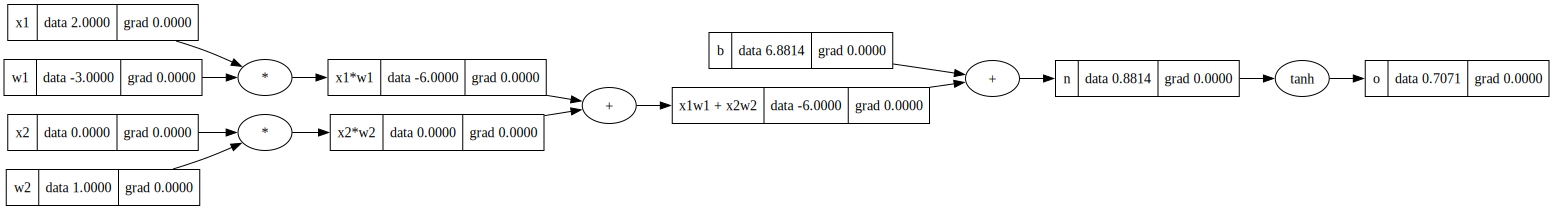

In [130]:
draw_dot(o)

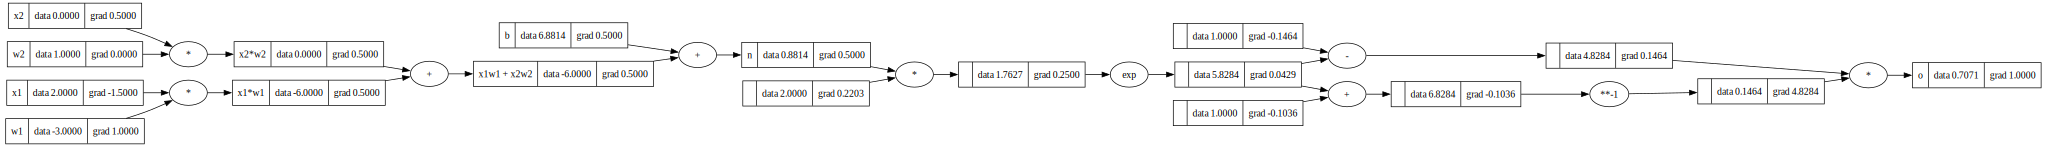

In [131]:
# inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#----
e = (n*2).exp()
o = (e -1) / (e + 1)
#----
o.label = 'o'
o.backward()
draw_dot(o)

In [132]:
import torch
import random

In [133]:
x1 = torch.Tensor([2.0]).double()                               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()                 ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())


0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w2 0.0


In [134]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return[p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range (len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [272]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.22524543033459093)

In [273]:
xs = [[2.0, 3.0, -1.0],
     [3.0, -1.0, 0.5],
     [0.5,1.0,1.0],
     [1.0,1.0,-1.0]
    ]

ys = [1.0,-1.0,-1.0,1.0] #desired targets



In [274]:

for k in range(100):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred))

    # zero gradients BEFORE backward pass
    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)

0 4.924171676091311
1 4.4358310407936425
2 4.184989600774975
3 4.02982275383373
4 3.9131082581669503
5 3.8055354544177735
6 3.686611505295736
7 3.53536572218643
8 3.322955846009273
9 3.004214614218525
10 2.515117369007079
11 1.8370833016229156
12 1.1640581557202947
13 0.7065324528963024
14 0.4352516620753405
15 0.2801772796416783
16 0.19462394284550197
17 0.1460617820409344
18 0.11622801876552952
19 0.09639492770599116
20 0.08234976050063712
21 0.07190802068977042
22 0.06384767996974064
23 0.05743850290846213
24 0.05221950047305352
25 0.047886120795264664
26 0.04422939351984436
27 0.04110128645699586
28 0.03839405217010468
29 0.03602741588395572
30 0.033940349535130816
31 0.032085629586717145
32 0.030426140518539646
33 0.028932304939625692
34 0.0275802595932715
35 0.026350536570923865
36 0.025227093787485985
37 0.02419659140698135
38 0.023247844389588386
39 0.022371403092772895
40 0.021559228283533065
41 0.02080443665266467
42 0.02010109959967861
43 0.019444082708087253
44 0.0188289166

In [275]:
ypred

[Value(data=0.9586773923052282),
 Value(data=-0.966626644451243),
 Value(data=-0.9453561911143317),
 Value(data=0.9674800643377298)]